<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Allison/MachineLearningTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

drive.mount('/content/drive')

#Loading Data
path = "/content/drive/MyDrive/Hospital_Inpatient_Discharges_2024.csv"
data = pd.read_csv(path)

#Looking at the Dataset Info
#print(data.shape)
#print(data.head())
#print(data.info())


Mounted at /content/drive


/tmp/ipython-input-1193276726.py:12: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


In [8]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2084650 entries, 1 to 2196736
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code                             object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       float64
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description           

,Health Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
1,New York City,Queens,7003001.0,1628.0,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,13490.00,15464.30
2,New York City,New York,7002054.0,1458.0,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,...,Moderate,Moderate,Medical,Medicare,Private Health Insurance,NaN,NaN,Y,49503.16,9324.77
3,New York City,New York,7002054.0,1464.0,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,...,Minor,Minor,Medical,Private Health Insurance,NaN,NaN,2700,Y,27827.66,7304.27
4,New York City,New York,7002032.0,1466.0,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicare,NaN,NaN,NaN,Y,32798.29,7948.10
5,New York City,Bronx,7000001.0,1178.0,BRONXCARE HOSPITAL CENTER,30-49,100,M,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,Medicaid,NaN,NaN,Y,21902.26,43136.54


In [9]:
#Looking at columns, which data would be useful to be included
print(data.columns.tolist())

['Health Service Area', 'Hospital County', 'Operating Certificate Number', 'Permanent Facility Id', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'Discharge Year', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description', 'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3', 'Birth Weight', 'Emergency Department Indicator', 'Total Charges', 'Total Costs']


In [11]:
data.drop(columns=['Health Service Area', 'Hospital County', 'Operating Certificate Number', 'Permanent Facility Id', 'Facility Name', 'Patient Disposition', 'Discharge Year', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code', 'APR DRG Description', 'APR MDC Code', 'APR MDC Description', 'APR Severity of Illness Code', 'APR Severity of Illness Description', 'APR Medical Surgical Description', 'Birth Weight', 'Emergency Department Indicator', 'Total Charges', 'Total Costs'])

,Age Group,Zip Code,Gender,Race,Ethnicity,Length of Stay,Type of Admission,APR Risk of Mortality,Payment Typology 1,Payment Typology 2,Payment Typology 3
1,0-17,113,M,White,Spanish/Hispanic,2.0,Emergency,Moderate,Medicaid,NaN,NaN
2,70 or Older,100,M,White,Not Span/Hispanic,2.0,Emergency,Moderate,Medicare,Private Health Insurance,NaN
3,0-17,100,F,Other Race,Not Span/Hispanic,1.0,Emergency,Minor,Private Health Insurance,NaN,NaN
4,18-29,100,F,Other Race,Spanish/Hispanic,1.0,Emergency,Minor,Medicare,NaN,NaN
5,30-49,100,M,Black/African American,Not Span/Hispanic,1.0,Emergency,Minor,Medicaid,Medicaid,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2196732,70 or Older,111,F,Multi-racial,Not Span/Hispanic,1.0,Elective,Moderate,Medicare,Medicare,Medicaid
2196733,18-29,136,F,White,Not Span/Hispanic,5.0,Elective,Minor,Federal/State/Local/VA,NaN,NaN
2196734,30-49,112,F,Black/African American,Unknown,3.0,Elective,Minor,Medicaid,NaN,NaN
2196735,30-49,117,F,White,Not Span/Hispanic,3.0,Elective,Moderate,Blue Cross/Blue Shield,NaN,NaN


In [12]:
#Creating a function to clean and prepare data set
def clean_data(df):

#Remove Duplicates
  df = df.drop_duplicates()

#Excluding the rows that do not have LOS; Missing data
  df = df.dropna(subset = ['Length of Stay'])

#Convert data to numerical, Drop those who can't convert
  df['Length of Stay'] = pd.to_numeric(df['Length of Stay'], errors='coerce')
  df = df.dropna(subset = ['Length of Stay'])

#Filter out data with invalid/non-numerical cases (e.g., some data '120+' or 'unkown')
  #df = df[df['Length of Stay'].apply(lambda x: str(x).replace('.', '', 1).isdigit())]

  df = df.dropna(subset = ['Length of Stay'])

#Remove out-of-state ZIP Codes ('OOS')
  df = df[df['Zip Code'] != 'OOS']

#Remove Outliers
  #upper_limit = df.['Length of Stay'].quantile(0.99)
  #df = df[(df['Length of Stay'] >0 ) & (df['Length of Stay'] <= upper_limit)]

#Columns/featured data to include with LOS
  data_features = ['Zip Code', 'Age Group', 'Gender', 'Race', 'Ethnicity',
                   'Type of Admission', 'APR Risk of Mortality', 'Payment Typology 1']

  df = df.dropna(subset = data_features)

  print(f"Cleaned Data: {len(df)} rows")
  return df

#Clean Data
data = clean_data(data)
duplicates = data[data.duplicated()]

print("Shape of cleaned data:", data.shape)  # rows, columns




Cleaned Data: 2084650 rows
Shape of cleaned data: (2084650, 33)


In [13]:
data_sample = data.sample(n = 1500000, random_state=42)

data_features = ['Zip Code', 'Age Group', 'Gender', 'Race', 'Ethnicity',
                   'Type of Admission', 'APR Risk of Mortality', 'Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']

data = data[data_features + ['Length of Stay']]

data.dtypes



,0
Zip Code,object
Age Group,object
Gender,object
Race,object
Ethnicity,object
Type of Admission,object
APR Risk of Mortality,object
Payment Typology 1,object
Payment Typology 2,object
Payment Typology 3,object


In [14]:
#Correlation for Numerical Data
numerical_columns = data.select_dtypes(include = ['int64', 'float64']).columns.tolist()
data[numerical_columns].describe()

numerical_columns.remove('Length of Stay')

data[numerical_columns].describe()

correlations = data[numerical_columns + ['Length of Stay']].corr()['Length of Stay'].sort_values(ascending = False)
print(correlations)

#Total Cost(0.69), Total Charges(0.66) strong positive, then Severity of Illness(0.35)

ValueError: Cannot describe a DataFrame without columns

In [ ]:
#ANOVA for Categorical Data
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()

#Converting categorical values to dummy/one-hot encoded variables
X_cat = pd.get_dummies(data[categorical_columns], drop_first = True)

y = data['Length of Stay']

scores = mutual_info_regression(X_cat, y, discrete_features = True)

scores = pd.Scores(scores, index = X_cat.columns).sort_values(ascending = False)

print(scores)

['Medicaid' nan 'Medicare' 'Private Health Insurance' 'Self-Pay'
 'Blue Cross/Blue Shield' 'Federal/State/Local/VA'
 'Managed Care, Unspecified' 'Miscellaneous/Other'
 'Department of Corrections']
                           Payment Typology 1  Payment Typology 2  \
Private Health Insurance               287820              142013   
Medicaid                               611950              410195   
Medicare                               893673              162911   
Self-Pay                                31623              114671   
Blue Cross/Blue Shield                 188450              101192   
Federal/State/Local/VA                  20082               12569   
Managed Care, Unspecified               29477                5386   
Miscellaneous/Other                     20050                2840   
Department of Corrections                1525                 106   

                           Payment Typology 3    Total  
Private Health Insurance                19069   448902 

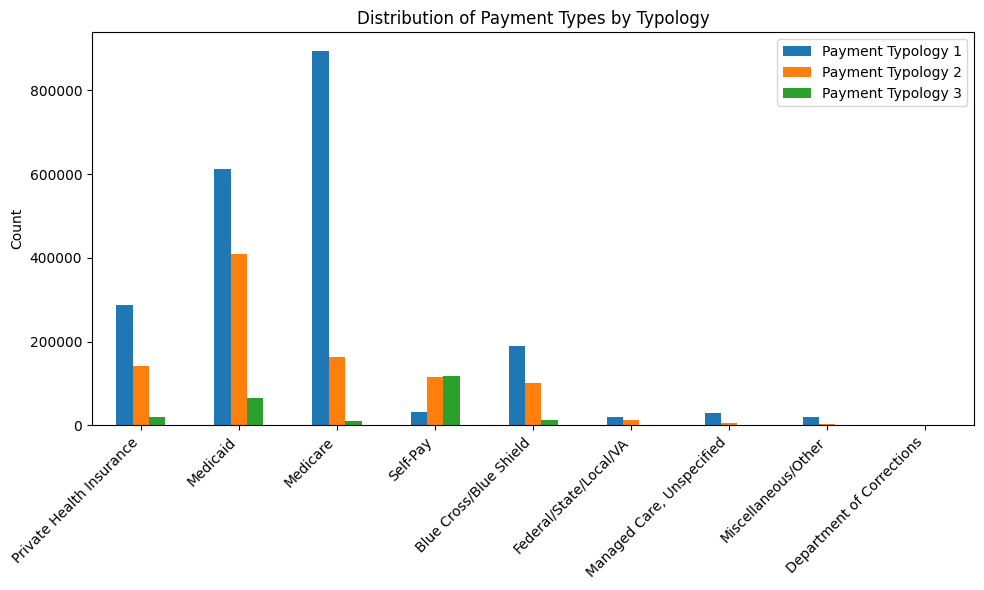

In [15]:
all_payment_types = pd.unique(data[['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']].values.ravel())
print(all_payment_types)

#Output for Payment Types
payment_types = ['Private Health Insurance', 'Medicaid', 'Medicare', 'Self-Pay', 'Blue Cross/Blue Shield',
                 'Federal/State/Local/VA', 'Managed Care, Unspecified',
                 'Miscellaneous/Other', 'Department of Corrections' ]

summary = {}

for i in [1, 2, 3]:
  col = f'Payment Typology {i}'
  counts = data[col].value_counts()
  summary[col] = {ptype: counts.get(ptype, 0) for ptype in payment_types}

payment_summary = pd.DataFrame(summary)

payment_summary['Total'] = payment_summary.sum(axis = 1)

print(payment_summary)


payment_summary[['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']].plot(
    kind='bar', figsize=(10,6), ylabel='Count',
    title='Distribution of Payment Types by Typology')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Breakdown each Payment Type
payment_breakdown = payment_summary[['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']].div(
    payment_summary[['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']].sum(), axis = 1)* 100

payment_breakdown = payment_breakdown.round(2)

print(payment_breakdown)


In [ ]:
#Setting up parameters,
X = data[data_features]
y = data['Length of Stay']

#Replaces text columns with numerical data (0/1)
X = pd.get_dummies(data[data_features])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state =42)

#Training model
model = RandomForestRegressor(n_estimators = 20, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

#Evaluating
mae = mean_absolute_error(y_test, y_pred) #The average absolute prediction error (in days)
print(f'Mean Absolute Error: {mae: .2f}')


#model predicts within ±3.91 days of the true hospital stay. Length of Stay differs from the actual stay by about 3.88 days.

Mean Absolute Error:  3.95


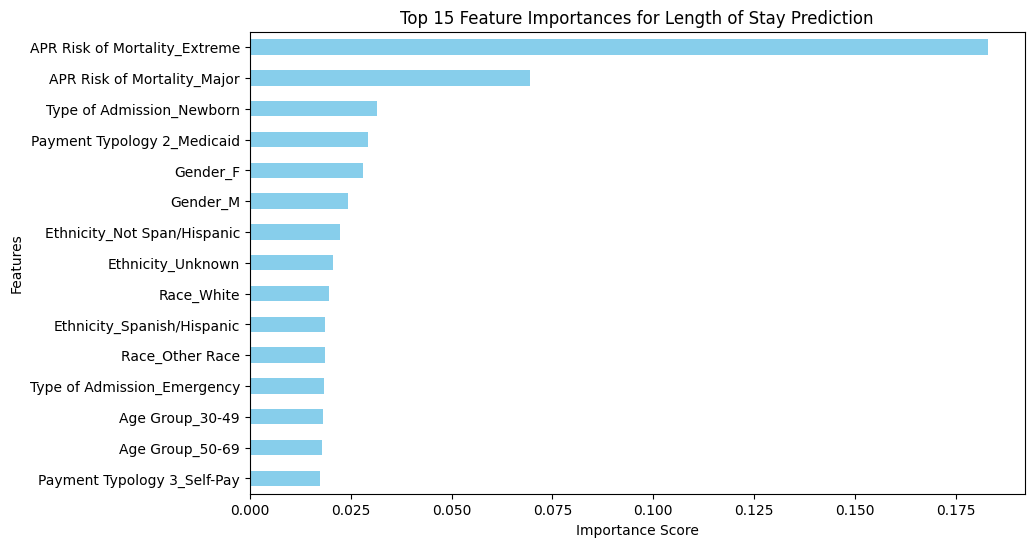

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances for Length of Stay Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [ ]:
import pandas as pd

#Zip to strings
data['Zip Code'] = data['Zip Code'].astype(str)

#Calculate Averages
zip_averages = data.groupby('Zip Code')['Length of Stay'].mean()

print(zip_averages.sort_values(ascending=False).head(10))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Plot Outliers
plt.figure(figsize = (10,5))
sns.boxplot(x = data['Length of Stay'])
plt.title('Potential Outliers on Length of Stay')
plt.show()

plt.figure(figsize = (8,5))
sns.histplot(data['Length of Stay'], bins = 40, kde = True)
plt.title('Distribution of Length of Stay')
plt.xlabel('Days')
plt.show()

data['Length of Stay'].describe()

In [ ]:
#from sklearn import tree
#from sklearn.tree import DecisionTreeRegressor, plot_tree

#model = DecisionTreeRegressor(criterion = 'squared_error', random_state = 42)
#model.fit(X_train, y_train)

#y_pred = model.predict(X_test)
#mae = mean_absolute_error(y_test, y_pred)
#print(f'Mean Absolute Error: {mae:2f}')

#plt.figure(figsize = (16,10))
#tree.plot_tree(model, filled = True, feature_names = X.columns, rounded = True, fontsize = 8)

#plt.title('Decision Tree for Length of Stay Prediction')
#plt.show